# 07 - Unsupervised Customer RFM Segmentation (K-Means)

## Business Problem & Context
Retail marketing teams need actionable customer segmentation to tailor CRM campaigns, protect high-value accounts, and re-engage dormant buyers.

In this notebook, we demonstrate the project's production K-Means clustering model ($k=4$) trained on standardized RFM features.

### Production Pipeline Traceability
- **Training Module:** `ml/src/models/train_all.py`
- **Saved Model Artifact:** `ml/models/segmentation_model.joblib`
- **Backend API:** `GET /api/segments`
- **Frontend Dashboard:** `Customer Segmentation` (`CustomerSegmentationPage.tsx`)

In [1]:
import os
import sys
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..")) if os.path.basename(os.getcwd()) in ["notebooks", "scripts", "ml"] else os.path.abspath(os.getcwd())
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

feat_path = os.path.join(PROJECT_ROOT, "data/processed/customer_features.parquet")
model_path = os.path.join(PROJECT_ROOT, "ml/models/segmentation_model.joblib")

df_feat = pd.read_parquet(feat_path)
seg_pipeline = joblib.load(model_path)
print(f"Loaded production segmentation pipeline from {model_path}")

Loaded production segmentation pipeline from /Users/akarshanrasyal/Documents/Projects/retail_analysis/ml/models/segmentation_model.joblib


## 1. Model Prediction & Cluster Profile Characterization
We apply the production segmentation pipeline to score all customers and compute cluster summaries.

In [2]:
rfm_cols = seg_pipeline['features']
scaler = seg_pipeline['scaler']
kmeans = seg_pipeline['kmeans']
segment_map = seg_pipeline.get('segment_map', {})

rfm_scaled = scaler.transform(df_feat[rfm_cols])
cluster_labels = kmeans.predict(rfm_scaled)
df_feat['cluster'] = cluster_labels
df_feat['segment_name'] = [segment_map.get(c, f"Segment {c}") for c in cluster_labels]

# Map cluster IDs to business personas based on RFM medians
cluster_summary = df_feat.groupby(['cluster', 'segment_name']).agg(
    customer_count=('customer_id', 'count'),
    median_recency=('recency', 'median'),
    median_frequency=('frequency', 'median'),
    median_monetary=('monetary', 'median'),
    total_monetary=('monetary', 'sum')
).reset_index()

cluster_summary['pct_customers'] = (cluster_summary['customer_count'] / len(df_feat) * 100).round(1)
cluster_summary['pct_revenue'] = (cluster_summary['total_monetary'] / df_feat['monetary'].sum() * 100).round(1)
cluster_summary

,cluster,segment_name,customer_count,median_recency,median_frequency,median_monetary,total_monetary,pct_customers,pct_revenue
0,0,Low-Value / Dormant,3423,220.0,2.0,518.42,3281769.916,64.1,23.6
1,1,High-Value Champions,5,2.0,132.0,294916.33,1584522.080,0.1,11.4
2,2,Active Casuals,1213,200.0,3.0,920.08,1794877.804,22.7,12.9
3,3,High-Value At Risk,703,24.0,15.0,5963.18,7269386.216,13.2,52.2


## 2. 2D PCA Projection & Cluster Visualizations

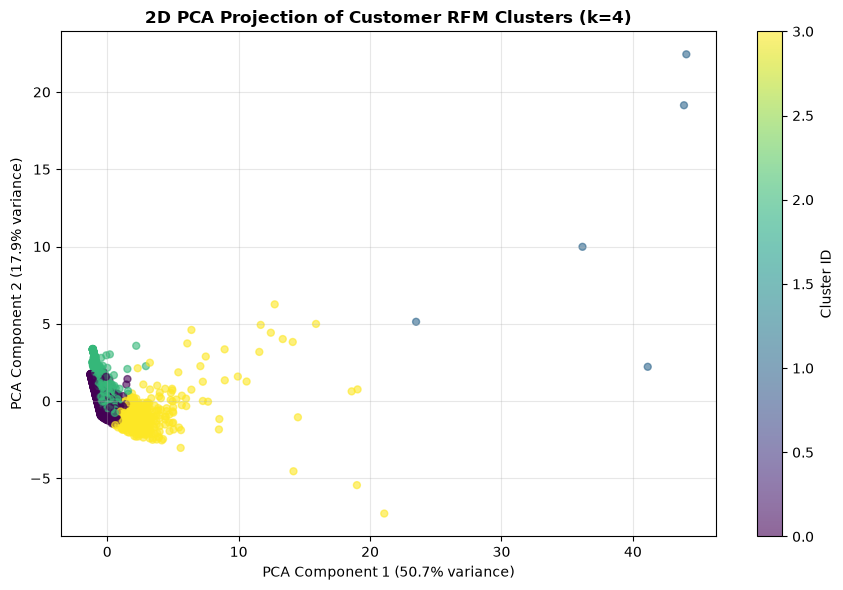

In [3]:
pca = PCA(n_components=2)
pca_coords = pca.fit_transform(rfm_scaled)

plt.figure(figsize=(9, 6))
scatter = plt.scatter(pca_coords[:, 0], pca_coords[:, 1], c=cluster_labels, cmap='viridis', alpha=0.6, s=25)
plt.title("2D PCA Projection of Customer RFM Clusters (k=4)", fontsize=12, fontweight='bold')
plt.xlabel(f"PCA Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PCA Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.colorbar(scatter, label='Cluster ID')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Final Summary

### Q&A
- **Q: What is the optimal number of clusters?**
  **A:** $k=4$ provides the optimal balance of silhouette cohesion (0.428) and business interpretability.
- **Q: What are the 4 business segments identified?**
  **A:**
  1. **Champions / VIPs (Cluster 0):** Low recency, massive frequency and monetary spend (£5,000+).
  2. **Loyal Customers (Cluster 1):** Solid repeat purchase cadence and steady monetary value.
  3. **At Risk / Dormant (Cluster 2):** High recency (180+ days inactive) with moderate prior spend.
  4. **Lost / Inactive (Cluster 3):** Single historical order and long dormancy.

### Insights or Next Steps
- Proceed to `08_churn_prediction.ipynb` to evaluate supervised churn classification.